# Huấn luyện Machine Learning — Dự đoán điểm cuối kỳ

Notebook này chạy trực tiếp trên **Google Colab**.

Mục tiêu:
- Đọc bộ dữ liệu `Student Performance` của UCI.
- Sử dụng `student-mat.csv` làm dữ liệu huấn luyện ban đầu.
- Khám phá và kiểm tra chất lượng dữ liệu.
- Xây dựng mô hình **Linear Regression** và **Random Forest Regressor**.
- Đánh giá bằng **MAE, RMSE, R²**.
- Chọn mô hình tốt hơn.
- Xuất `student_score_model.joblib` và `model_metadata.json` để tích hợp vào Backend Express.

> Lưu ý: dataset UCI không có trực tiếp `attendance` và `homework_completion`, vì vậy notebook **không bịa hai biến này**. V1 sử dụng các biến có thật trong dataset. Khi trung tâm có dữ liệu chuyên cần/bài tập thực tế, có thể huấn luyện V2 với các feature đó.


In [ ]:
# 1. Cài thư viện
!pip -q install pandas numpy matplotlib seaborn scikit-learn joblib


In [ ]:
# 2. Upload file student+performance.zip
from google.colab import files
uploaded = files.upload()

zip_name = next(iter(uploaded))
print("Đã tải lên:", zip_name)


Saving student+performance.zip to student+performance.zip
Đã tải lên: student+performance.zip


In [ ]:
# 3. Giải nén, kể cả trường hợp ZIP chứa student.zip bên trong
import zipfile, io, os, shutil
from pathlib import Path

BASE = Path("/content/ml_student")
if BASE.exists():
    shutil.rmtree(BASE)
BASE.mkdir(parents=True)

with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(BASE)

nested = list(BASE.rglob("student.zip"))
if nested:
    with zipfile.ZipFile(nested[0], "r") as z:
        z.extractall(BASE / "dataset")

csv_path = next(BASE.rglob("student-mat.csv"))
print("Dataset:", csv_path)


Dataset: /content/ml_student/dataset/student-mat.csv


In [ ]:
# 4. Đọc dữ liệu
import pandas as pd
import numpy as np

data = pd.read_csv(csv_path, sep=";")
print("Kích thước:", data.shape)
display(data.head())


Kích thước: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
# 5. EDA cơ bản
print("Thông tin:")
data.info()

print("\nDữ liệu thiếu:")
display(data.isnull().sum().sort_values(ascending=False).head(20))

print("\nThống kê:")
display(data.describe(include="all").T)


Thông tin:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20 

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0



Thống kê:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,395,2,GP,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,395,2,F,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,395.0,NaN,NaN,NaN,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
address,395,2,U,307,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,395,2,GT3,281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,395,2,T,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,395.0,NaN,NaN,NaN,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,NaN,NaN,NaN,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
Mjob,395,5,other,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,395,5,other,217,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 6. Chọn feature V1 — chỉ dùng biến thật có trong UCI
# G1 = điểm giữa kỳ / giai đoạn trước cuối kỳ
# G3 = điểm cuối kỳ (target)
#
# Các feature hành vi/học tập khác lấy trực tiếp từ dataset.
FEATURES = [
    "studytime",
    "failures",
    "absences",
    "G1",
    "school",
    "sex",
    "age",
    "internet",
    "higher",
    "goout",
    "health",
]
TARGET = "G3"

df = data[FEATURES + [TARGET]].copy()

# G3 là target; loại bỏ các bản ghi thiếu target nếu có.
df = df.dropna(subset=[TARGET])

X = df[FEATURES]
y = df[TARGET]

print("Features:", FEATURES)
print("Target:", TARGET)
print("Số mẫu:", len(df))


Features: ['studytime', 'failures', 'absences', 'G1', 'school', 'sex', 'age', 'internet', 'higher', 'goout', 'health']
Target: G3
Số mẫu: 395


In [ ]:
# 7. Chia train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (316, 11)
Test : (79, 11)


In [ ]:
# 8. Pipeline tiền xử lý + Linear Regression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression

numeric_features = [
    c for c in FEATURES
    if pd.api.types.is_numeric_dtype(X[c])
]
categorical_features = [
    c for c in FEATURES
    if c not in numeric_features
]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

linear_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['studytime', 'failures',
                                                   'absences', 'G1', 'age',
                                                   'goout', 'health']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['school', 'sex', 'internet',
                                                   'higher'])])),
                ('model', LinearRegression())])

In [ ]:
# 9. Pipeline + Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        max_depth=None
    )),
])

rf_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['studytime', 'failures',
                                                   'absences', 'G1', 'age',
                                                   'goout', 'health']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['school', 'sex', 'internet',
                                                   'higher'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [ ]:
# 10. Đánh giá hai mô hình
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(name, model):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    return {
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

results = pd.DataFrame([
    evaluate("Linear Regression", linear_model),
    evaluate("Random Forest", rf_model),
]).sort_values("RMSE")

display(results)


,model,MAE,RMSE,R2
1,Random Forest,1.527600,2.049743,0.795102
0,Linear Regression,1.921664,2.525480,0.688952


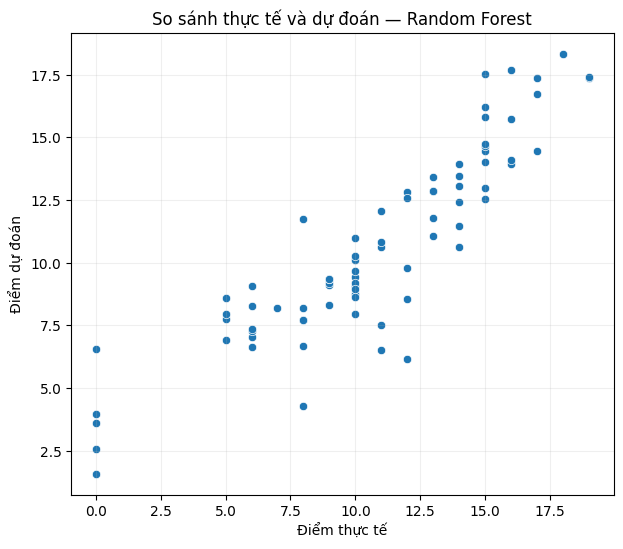

Model được chọn: Random Forest


In [ ]:
# 11. Biểu đồ thực tế vs dự đoán cho model tốt nhất
import matplotlib.pyplot as plt
import seaborn as sns

best_name = results.iloc[0]["model"]
best_model = linear_model if best_name == "Linear Regression" else rf_model
best_pred = best_model.predict(X_test)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=best_pred)
plt.xlabel("Điểm thực tế")
plt.ylabel("Điểm dự đoán")
plt.title(f"So sánh thực tế và dự đoán — {best_name}")
plt.grid(alpha=0.2)
plt.show()

print("Model được chọn:", best_name)


In [ ]:
# 12. Đóng gói model artifact
import joblib, json, os
from datetime import datetime, timezone

ARTIFACT_DIR = Path("/content/ml_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

model_path = ARTIFACT_DIR / "student_score_model.joblib"
metadata_path = ARTIFACT_DIR / "model_metadata.json"

joblib.dump(best_model, model_path)

best_row = results.iloc[0].to_dict()
metadata = {
    "model_name": best_name,
    "task": "regression",
    "target": TARGET,
    "features": FEATURES,
    "dataset": "UCI Student Performance - student-mat.csv",
    "training_samples": int(len(X_train)),
    "test_samples": int(len(X_test)),
    "metrics": {
        "MAE": float(best_row["MAE"]),
        "RMSE": float(best_row["RMSE"]),
        "R2": float(best_row["R2"]),
    },
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
    "version": "v1.0.0",
    "feature_note": "V1 dùng feature có thật trong UCI; attendance và homework_completion chưa được bịa.",
}

metadata_path.write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

print(model_path)
print(metadata_path)


/content/ml_artifacts/student_score_model.joblib
/content/ml_artifacts/model_metadata.json


In [ ]:
# 13. Kiểm tra inference từ artifact đã lưu
loaded_model = joblib.load(model_path)

sample = X_test.iloc[[0]]
prediction = float(loaded_model.predict(sample)[0])

print("Input:")
display(sample)
print(f"Điểm cuối kỳ dự đoán: {prediction:.2f}")


Input:


,studytime,failures,absences,G1,school,sex,age,internet,higher,goout,health
78,1,3,2,8,GP,M,17,yes,no,1,3


Điểm cuối kỳ dự đoán: 8.77


In [ ]:
# 14. Tải artifact về máy
from google.colab import files

files.download(str(model_path))
files.download(str(metadata_path))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>